## 1. Импорт зависимостей

In [15]:
import sys
from pathlib import Path
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf
from match import CONFIG_DIR, resolve_project_path, normalize_attributes, train_maxpooling_model

with initialize_config_dir(version_base=None, config_dir=str(CONFIG_DIR)):
    cfg = compose(config_name="prepare_data")

pl.Config.set_tbl_rows(-1)       # показывать все строки
pl.Config.set_tbl_cols(-1)       # показывать все столбцы
pl.Config.set_fmt_str_lengths(1000)  # не обрезать длинные строки
pl.Config.set_tbl_width_chars(200)   # ширина таблицы

polars.config.Config

## 2. Чтение конфига

In [16]:
cfg

{'path': {'items_human_path': 'data/items_human.parquet', 'matches_human_path': 'data/matches.parquet', 'items_human_normalized_path': 'data/items_human_normalized.parquet', 'synonyms': 'data/synonyms.parquet', 'unique_attributes': 'data/unique_attributes.parquet', 'matches_llm': 'data/matches_llm.parquet', 'items': 'data/items.parquet', 'train_matches': 'data/train_matches.parquet'}}

## 3. Чтение датасета

In [17]:
df_human = pl.read_parquet(resolve_project_path(cfg.path.items_human_path))
df_matches = pl.read_parquet(resolve_project_path(cfg.path.matches_human_path))
# df = pl.read_parquet(resolve_project_path(cfg.path["items"]))
synonyms_df = pl.read_parquet(resolve_project_path(cfg.path.synonyms))
unique_attributes = pl.read_parquet(resolve_project_path(cfg.path.unique_attributes))
df_human.head(1), df_matches.head(1), synonyms_df.head(1), unique_attributes.head(1)

(shape: (1, 4)
 ┌─────┬────────────────────────────────────────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────┐
 │ id  ┆ name                                                       ┆ attributes                                                                                                           ┆ category   │
 │ --- ┆ ---                                                        ┆ ---                                                                                                                  ┆ ---        │
 │ i64 ┆ str                                                        ┆ str                                                                                                                  ┆ str        │
 ╞═════╪════════════════════════════════════════════════════════════╪════════════════════════════════════════════════════════════════════════════════════════════════════════════

## 3.2 Разбор карточек которые совпадают

In [5]:
df_matches.filter(pl.col("target") == 1).head()

id1,id2,target
i64,i64,f64
476,841813632218,1.0
525,13777,1.0
622,360777364649,1.0
706,352187426187,1.0
753,747324374388,1.0


In [6]:
row = df_matches.filter(pl.col("target") == 1).sample(1)
id1, id2 = row.select("id1", "id2").row(0)


item1 = (
    df_human
    .filter(pl.col("id") == id1)
    .select("id", "name", "normalized_attributes")
    .row(0, named=True)
)

item2 = (
    df_human
    .filter(pl.col("id") == id2)
    .select("id", "name", "normalized_attributes")
    .row(0, named=True)
)


attrs1 = json.loads(item1["normalized_attributes"])
attrs2 = json.loads(item2["normalized_attributes"])

all_keys = sorted(set(attrs1) | set(attrs2))


names = pl.DataFrame({
    "id": [item1["id"], item2["id"]],
    "name": [item1["name"], item2["name"]],
})

comparison = (
    pl.DataFrame({
        "attribute": all_keys,
        f"value_{id1}": [attrs1.get(key) for key in all_keys],
        f"value_{id2}": [attrs2.get(key) for key in all_keys],
    })
    .with_columns(
        (
            pl.col(f"value_{id1}").fill_null("<нет>")
            == pl.col(f"value_{id2}").fill_null("<нет>")
        ).alias("equal")
    )
    .sort(["equal", "attribute"], descending=[True, False])
)

display(names)
display(comparison)

id,name
i64,str
601295483944,"""блесна колебалка akara action series kola 18гр. ab47"""
481036415187,"""блесна колеб. akara action series kola 90 21гр. 3/4oz. ab47"""


attribute,value_601295483944,value_481036415187,equal
str,str,str,bool
"""бренд""",null,"""akara""",false
"""вес, г""",null,"""21""",false
"""вес, кг""","""0.018000000000000002""",null,false
"""длина, мм""","""70""",null,false
"""длина, см""",null,"""9""",false
"""название цвета""",null,"""ab47""",false
"""плавучесть""","""быстро тонущая""",null,false
"""сезон снасти""",null,"""лето""",false
"""страна-производитель""",null,"""китай""",false


## 4. Дисбаланс класса 1/4

In [7]:
attrs = json.loads(df_human.filter(pl.col("id") == id1).select("attributes").to_series().to_list()[0])
attrs.keys()

dict_keys(['цвет товара', 'тип', 'длина', 'вес', 'вид крючка/вертлюжка', 'вид', 'плавучесть', 'вид рыбы'])

In [8]:
(
    df_matches
    .group_by("target")
    .agg(pl.count().alias("count"))
    .with_columns(
        (pl.col("count") / pl.sum("count")).alias("ratio")
    )
    .sort("target")
)

C:\Users\Samoylov_Nikita\AppData\Local\Temp\ipykernel_30224\3475110605.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("count"))


target,count,ratio
f64,u32,f64
0.0,271764,0.743227
1.0,93890,0.256773


## 5. Разбор датасета товаров

In [9]:
df_human.head()

id,name,attributes,category,normalized_attributes
i64,str,str,str,str
197,"""victor reinz прокладка впускного коллектора арт. 703315700""","""{""артикул"":""703315700"",""бренд"":""victor reinz"",""партномер (артикул производителя)"":""703315700"",""тип"":""прокладка двигателя"",""вид техники"":""легковые автомобили""}""","""Автотовары""","""{""артикул"": ""703315700"", ""бренд"": ""victor reinz"", ""партномер (артикул производителя)"": ""703315700"", ""тип"": ""прокладка двигателя"", ""тип системы"": ""легковые автомобили""}"""
415,"""stellox диск тормозной, арт. 8500892sx""","""{""артикул"":""stellox_8500892sx"",""место установки"":""передние"",""толщина тормозного диска, мм"":""28"",""бренд"":""stellox"",""oem-номер"":""3050086; a9064210012; 2e0615301; 68006716aa; 9064210012; 9064210212; 9064210012s; 9064210112"",""партномер (артикул производителя)"":""8500892sx"",""тип"":""диск тормозной"",""тип тормозного диска"":""вентилируемый"",""вид техники"":""легковые автомобили""}""","""Автотовары""","""{""артикул"": ""stellox_8500892sx"", ""система установки"": ""передние"", ""толщина тормозного диска, мм"": ""28"", ""бренд"": ""stellox"", ""oem-номер"": ""3050086; a9064210012; 2e0615301; 68006716aa; 9064210012; 9064210212; 9064210012s; 9064210112"", ""партномер (артикул производителя)"": ""8500892sx"", ""тип"": ""диск тормозной"", ""тип тормозного диска"": ""вентилируемый"", ""тип системы"": ""легковые автомобили""}"""
427,"""комплект подшипника ступицы колеса lynxauto""","""{""артикул производителя"":"""",""бренд"":""lynxauto"",""примечание"":""внешний вид изделия может отличаться от фотографий"",""цена за"":""1 шт."",""код товара"":""600000256748""}""","""Автотовары""","""{""артикул производителя"": """", ""бренд"": ""lynxauto"", ""примечание"": ""внешний вид изделия может отличаться от фотографий"", ""плата за"": ""1 шт."", ""код товара"": ""600000256748""}"""
1027,"""kraft подшипник ступицы, арт. kt204632, 1 шт.""","""{""артикул"":""112097-01"",""бренд"":""kraft"",""количество в упаковке, шт"":""1"",""партномер (артикул производителя)"":""kt204632"",""тип"":""подшипник ступицы""}""","""Автотовары""","""{""артикул"": ""112097-01"", ""бренд"": ""kraft"", ""количество в упаковке, шт"": ""1"", ""партномер (артикул производителя)"": ""kt204632"", ""тип"": ""подшипник ступицы""}"""
2639,"""фильтр салонный skoda fabia 00-""","""{""альтернативные артикулы товара"":""8104400xkz96a;50013702;ac0110c;50013941;9.7.84;la120;if-3019;afc1076;ac9403;ca-49010;6q0820367b;fs089;lak120;sab 123;1987432057;1010-026;6q0819653;6q0819653b;9.7.147;ac0110c;fs-089;dfc2545;if3019k;if3019p;sa1123;afw1076;gb9892c;fcr21f061;jdacx055;lac-1006;7110221sx;7110247sx;1cf031;nfe-2389;k1079;cuk2545;wc4015;7110543sx;st-6q0820367b;nf6123c;sa 1123;pf2123;mc-e4072;nf6123;1cf041;pf2041;lac1006c;8104400xkz96a\n"",""артикул"":""cu2545"",""бренд"":""sat"",""страна-изготовитель"":""китай"",""oem-номер"":""8104400xkz96a;50013702;ac0110c;50013941;9.7.84;la120;if-3019;afc1076;ac9403;ca-49010;6q0820367b;fs089;lak120;sab 123;1987432057;1010-026;6q0819653;6q0819653b;9.7.147;ac0110c;fs-089;dfc2545;if3019k;if3019p;sa1123;afw1076;gb9892c;fcr21f061;jdacx055;lac-1006;7110221sx;7110247sx;1cf031;nfe-2389;k1079;cuk2545;wc4015;7110543sx;st-6q0820367b;nf6123c;sa 1123;pf2123;mc-e4072;nf6123;1cf041;pf2041;lac1006c;8104400xkz96a\n"",""комплектация"":""фильтр салона для авто 1 шт"",""партномер (…","""Автотовары""","""{""альтернативные артикулы товара"": ""8104400xkz96a;50013702;ac0110c;50013941;9.7.84;la120;if-3019;afc1076;ac9403;ca-49010;6q0820367b;fs089;lak120;sab 123;1987432057;1010-026;6q0819653;6q0819653b;9.7.147;ac0110c;fs-089;dfc2545;if3019k;if3019p;sa1123;afw1076;gb9892c;fcr21f061;jdacx055;lac-1006;7110221sx;7110247sx;1cf031;nfe-2389;k1079;cuk2545;wc4015;7110543sx;st-6q0820367b;nf6123c;sa 1123;pf2123;mc-e4072;nf6123;1cf041;pf2041;lac1006c;8104400xkz96a"", ""артикул"": ""cu2545"", ""бренд"": ""sat"", ""страна-производитель"": ""китай"", ""oem-номер"": ""8104400xkz96a;50013702;ac0110c;500

## 6. Нормализация атрибутов

In [10]:
df_norm_human = normalize_attributes(df_human, resolve_project_path(cfg.path.synonyms), resolve_project_path(cfg.path.unique_attributes))

2026-08-17 00:30:19.043 | INFO     | match.normalization:normalize_attributes:440 - Starting attribute normalization: rows=711304, source_column='attributes', output_column='normalized_attributes'
2026-08-17 00:30:20.657 | INFO     | match.normalization:normalize_attributes:455 - Loaded normalization metadata: synonym_replacements=946, unique_attributes=26552
2026-08-17 00:30:20.658 | INFO     | match.normalization:normalize_attributes:470 - Using process-based normalization: n_jobs=4, chunk_size=5000, chunks=143


KeyboardInterrupt: 

In [ ]:
df_norm_human.head(1)

id,name,attributes,category,normalized_attributes
i64,str,str,str,str
197,"""victor reinz прокладка впускного коллектора арт. 703315700""","""{""артикул"":""703315700"",""бренд"":""victor reinz"",""партномер (артикул производителя)"":""703315700"",""тип"":""прокладка двигателя"",""вид техники"":""легковые автомобили""}""","""Автотовары""","""{""артикул"": ""703315700"", ""бренд"": ""victor reinz"", ""партномер (артикул производителя)"": ""703315700"", ""тип"": ""прокладка двигателя"", ""тип системы"": ""легковые автомобили""}"""


In [ ]:
row = df_matches.filter(pl.col("target") == 1).sample(1)
id1, id2 = row.select("id1", "id2").row(0)


item1 = (
    df_norm_human
    .filter(pl.col("id") == id1)
    .select("id", "name", "normalized_attributes")
    .row(0, named=True)
)

item2 = (
    df_norm_human
    .filter(pl.col("id") == id2)
    .select("id", "name", "normalized_attributes")
    .row(0, named=True)
)


attrs1 = json.loads(item1["normalized_attributes"])
attrs2 = json.loads(item2["normalized_attributes"])

all_keys = sorted(set(attrs1) | set(attrs2))


names = pl.DataFrame({
    "id": [item1["id"], item2["id"]],
    "name": [item1["name"], item2["name"]],
})

comparison = (
    pl.DataFrame({
        "attribute": all_keys,
        f"value_{id1}": [attrs1.get(key) for key in all_keys],
        f"value_{id2}": [attrs2.get(key) for key in all_keys],
    })
    .with_columns(
        (
            pl.col(f"value_{id1}").fill_null("<нет>")
            == pl.col(f"value_{id2}").fill_null("<нет>")
        ).alias("equal")
    )
    .sort(["equal", "attribute"], descending=[True, False])
)

display(names)
display(comparison)

id,name
i64,str
369367299603,"""alleva / alleva для стерилизованных кошек курица утка, 1,5 кг"""
670015038015,"""alleva holistic курица, утка сухой корм для взрослых стерилизованных кошек и кастрированных котов, а также животных, постоянно живущих в помещении, 1,5 кг"""


attribute,value_369367299603,value_670015038015,equal
str,str,str,bool
"""артикул""",null,"""002882""",false
"""бренд""",null,"""alleva""",false
"""валюта""","""rub""",null,false
"""вес товара, кг""",null,"""1.5""",false
"""вкус корма для животных""",null,"""курица""",false
"""возраст животного""","""взрослый""","""для взрослых""",false
"""высота упаковки, мм""","""90""","""100""",false
"""длина упаковки, мм""","""310""","""200""",false
"""кол в одном товаре""",null,"""1""",false


In [ ]:
id1 = 369367299603
id2 = 670015038015
row = df_matches.filter(pl.col("target") == 1).sample(1)
# id1, id2 = row.select("id1", "id2").row(0)


item1 = (
    df_norm_human
    .filter(pl.col("id") == id1)
    .select("id", "name", "attributes")
    .row(0, named=True)
)

item2 = (
    df_norm_human
    .filter(pl.col("id") == id2)
    .select("id", "name", "attributes")
    .row(0, named=True)
)


attrs1 = json.loads(item1["attributes"])
attrs2 = json.loads(item2["attributes"])

all_keys = sorted(set(attrs1) | set(attrs2))


names = pl.DataFrame({
    "id": [item1["id"], item2["id"]],
    "name": [item1["name"], item2["name"]],
})

comparison = (
    pl.DataFrame({
        "attribute": all_keys,
        f"value_{id1}": [attrs1.get(key) for key in all_keys],
        f"value_{id2}": [attrs2.get(key) for key in all_keys],
    })
    .with_columns(
        (
            pl.col(f"value_{id1}").fill_null("<нет>")
            == pl.col(f"value_{id2}").fill_null("<нет>")
        ).alias("equal")
    )
    .sort(["equal", "attribute"], descending=[True, False])
)

display(names)
display(comparison)

id,name
i64,str
369367299603,"""alleva / alleva для стерилизованных кошек курица утка, 1,5 кг"""
670015038015,"""alleva holistic курица, утка сухой корм для взрослых стерилизованных кошек и кастрированных котов, а также животных, постоянно живущих в помещении, 1,5 кг"""


attribute,value_369367299603,value_670015038015,equal
str,str,str,bool
"""артикул""",null,"""002882""",false
"""бренд""",null,"""alleva""",false
"""валюта""","""rub""",null,false
"""вес товара, г""",null,"""1500""",false
"""вид вкуса корма""","""птица""",null,false
"""вид животного""","""для кошек""",null,false
"""вкус корма для животных""",null,"""курица""",false
"""возраст животного""","""взрослый""","""для взрослых""",false
"""высота упаковки""","""9 см""",null,false


## 7. Обучение макспула

In [12]:
train_maxpooling_model(pl.read_parquet(resolve_project_path(cfg.path.items_human_path)), pl.read_parquet(resolve_project_path(cfg.path.matches_human_path)))

2026-08-17 00:33:03.446 | INFO     | match.maxpooling:_train_fasttext:146 - Training internal FastText: documents=711232, vector_size=256, epochs=10, workers=8
2026-08-17 00:56:10.438 | INFO     | match.maxpooling:_train_classifier:435 - Classifier epoch 1/50: train_loss=0.8762, val_loss=0.8507, val_roc_auc=0.7675, val_pr_auc=0.5284
2026-08-17 00:56:17.743 | INFO     | match.maxpooling:_train_classifier:435 - Classifier epoch 2/50: train_loss=0.8513, val_loss=0.8438, val_roc_auc=0.7725, val_pr_auc=0.5346
2026-08-17 00:56:24.962 | INFO     | match.maxpooling:_train_classifier:435 - Classifier epoch 3/50: train_loss=0.8401, val_loss=0.8424, val_roc_auc=0.7724, val_pr_auc=0.5346
2026-08-17 00:56:32.199 | INFO     | match.maxpooling:_train_classifier:435 - Classifier epoch 4/50: train_loss=0.8310, val_loss=0.8371, val_roc_auc=0.7768, val_pr_auc=0.5422
2026-08-17 00:56:39.236 | INFO     | match.maxpooling:_train_classifier:435 - Classifier epoch 5/50: train_loss=0.8226, val_loss=0.8357, val

MaxPoolingModel(_fasttext=<gensim.models.fasttext.FastText object at 0x0000025693B66E40>, _scaler=StandardScaler(), _classifier=PairMLP(
  (network): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
), vector_size=256, best_validation_auc=0.781483182097018, best_validation_pr_auc=0.5483653630227623)

## 8. Распределение длин текста и атрибутов

In [ ]:
import heapq
import json
from array import array
from collections.abc import Mapping

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm


# Укажи свой DataFrame:
items_df = df_human


# Используем компактные массивы, чтобы не хранить миллионы Python-int.
lengths = {
    "name": array("I"),
    "raw_attributes_json": array("I"),
    "unfolded_attributes": array("I"),
    "attribute_key": array("I"),
    "attribute_value": array("I"),
    "key_value_attribute": array("I"),
}

attribute_counts = array("I")

invalid_json_count = 0
empty_attributes_count = 0

TOP_K = 20
top_keys = []
top_values = []
top_attributes = []
heap_counter = 0


def parse_attributes(raw):
    """Преобразовать JSON-строку или Mapping в обычный dict."""
    if raw is None:
        return {}

    if isinstance(raw, Mapping):
        return dict(raw)

    if isinstance(raw, bytes):
        raw = raw.decode("utf-8")

    if isinstance(raw, str):
        if not raw.strip():
            return {}

        parsed = json.loads(raw)

        if not isinstance(parsed, dict):
            raise ValueError("attributes должен содержать JSON-объект")

        return parsed

    raise TypeError(
        f"Неожиданный тип attributes: {type(raw).__name__}"
    )


def value_to_text(value):
    """Преобразовать значение атрибута в текст."""
    if value is None:
        return ""

    if isinstance(value, (dict, list, tuple)):
        return json.dumps(value, ensure_ascii=False)

    return str(value)


def raw_attributes_to_text(raw):
    """Получить исходное строковое представление JSON."""
    if raw is None:
        return ""

    if isinstance(raw, bytes):
        return raw.decode("utf-8")

    if isinstance(raw, str):
        return raw

    if isinstance(raw, Mapping):
        return json.dumps(raw, ensure_ascii=False)

    return str(raw)


def add_top(heap, length, record):
    """Сохранить TOP_K самых длинных примеров."""
    global heap_counter

    heap_counter += 1
    item = (length, heap_counter, record)

    if len(heap) < TOP_K:
        heapq.heappush(heap, item)
    elif length > heap[0][0]:
        heapq.heapreplace(heap, item)


def iter_item_rows(df):
    """Итерирование по Pandas или Polars DataFrame."""
    columns = ["id", "name", "attributes"]

    if hasattr(df, "iter_rows"):  # Polars
        yield from df.select(columns).iter_rows(named=True)
        return

    # Pandas
    for item_id, name, attributes in df[columns].itertuples(
        index=False,
        name=None,
    ):
        yield {
            "id": item_id,
            "name": name,
            "attributes": attributes,
        }


total_rows = len(items_df)

for row in tqdm(
    iter_item_rows(items_df),
    total=total_rows,
    desc="Analyzing attributes",
):
    item_id = row["id"]
    name = "" if row["name"] is None else str(row["name"])
    raw_attributes = row["attributes"]

    lengths["name"].append(len(name))
    lengths["raw_attributes_json"].append(
        len(raw_attributes_to_text(raw_attributes))
    )

    try:
        attributes = parse_attributes(raw_attributes)
    except (json.JSONDecodeError, TypeError, ValueError):
        invalid_json_count += 1
        attributes = {}

    attribute_counts.append(len(attributes))

    if not attributes:
        empty_attributes_count += 1
        lengths["unfolded_attributes"].append(0)
        continue

    unfolded_parts = []

    for key, value in attributes.items():
        key_text = str(key)
        value_text = value_to_text(value)
        attribute_text = f"{key_text}: {value_text}"

        key_length = len(key_text)
        value_length = len(value_text)
        attribute_length = len(attribute_text)

        lengths["attribute_key"].append(key_length)
        lengths["attribute_value"].append(value_length)
        lengths["key_value_attribute"].append(attribute_length)

        unfolded_parts.append(attribute_text)

        common = {
            "id": item_id,
            "name": name,
            "key": key_text,
            "value_preview": value_text[:500],
            "key_chars": key_length,
            "value_chars": value_length,
            "attribute_chars": attribute_length,
        }

        add_top(top_keys, key_length, common)
        add_top(top_values, value_length, common)
        add_top(top_attributes, attribute_length, common)

    # Пример представления всей карточки после разворачивания.
    unfolded_text = " ".join(unfolded_parts)
    lengths["unfolded_attributes"].append(len(unfolded_text))


def to_numpy(values):
    return np.frombuffer(values, dtype=np.uint32)


def describe(values):
    values = to_numpy(values)

    if len(values) == 0:
        return {}

    return {
        "count": len(values),
        "mean": values.mean(),
        "p50": np.percentile(values, 50),
        "p75": np.percentile(values, 75),
        "p90": np.percentile(values, 90),
        "p95": np.percentile(values, 95),
        "p97": np.percentile(values, 97),
        "p99": np.percentile(values, 99),
        "p99.5": np.percentile(values, 99.5),
        "p99.9": np.percentile(values, 99.9),
        "max": values.max(),
        ">32, %": (values > 32).mean() * 100,
        ">64, %": (values > 64).mean() * 100,
        ">128, %": (values > 128).mean() * 100,
        ">256, %": (values > 256).mean() * 100,
        ">512, %": (values > 512).mean() * 100,
        ">1024, %": (values > 1024).mean() * 100,
    }


length_summary = pd.DataFrame(
    {
        name: describe(values)
        for name, values in lengths.items()
    }
).round(2)

attribute_count_summary = pd.Series(
    describe(attribute_counts),
    name="attributes_per_item",
).round(2)

display(length_summary)
display(attribute_count_summary.to_frame())


print("Некорректных JSON:", invalid_json_count)
print("Карточек без атрибутов:", empty_attributes_count)


def heap_to_frame(heap):
    records = [
        record
        for _, _, record in sorted(heap, reverse=True)
    ]
    return pd.DataFrame(records)


print("Самые длинные ключи:")
display(heap_to_frame(top_keys))

print("Самые длинные значения:")
display(heap_to_frame(top_values))

print("Самые длинные отдельные атрибуты key: value:")
display(heap_to_frame(top_attributes))

## 9. Анализ llm разметки

In [18]:
df_llm_matches = pl.read_parquet(resolve_project_path(cfg.path.matches_llm))
df_llm_matches.head()

id1,id2,target
i64,i64,f64
0,335007550085,0.888889
4,704374731307,0.0
5,343597509210,0.0
5,515396145486,0.0
5,541166037596,0.0


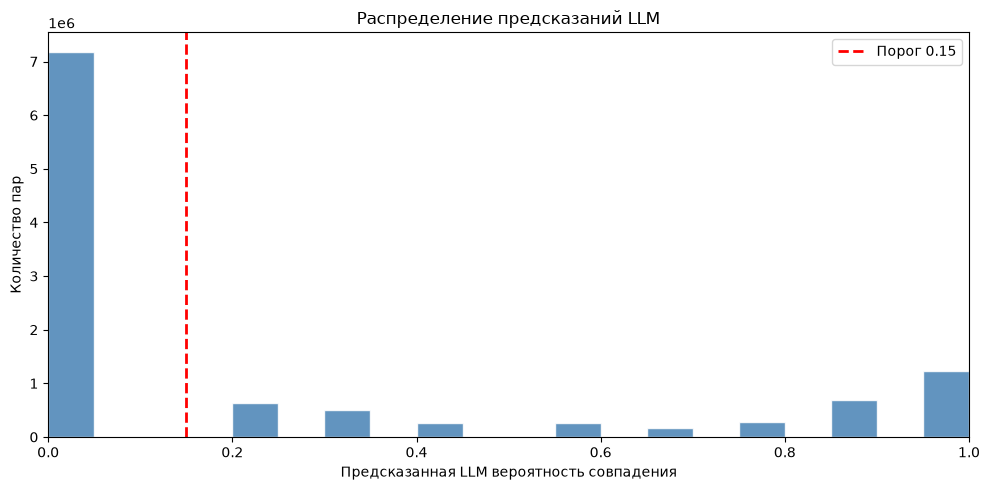

In [19]:
scores = np.asarray(df_llm_matches["target"].drop_nulls(), dtype=float)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    scores,
    bins=np.linspace(0, 1, 21),  # 40 одинаковых интервалов
    color="steelblue",
    edgecolor="white",
    alpha=0.85,
)

ax.axvline(
    0.15,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Порог 0.15",
)

ax.set_xlim(0, 1)
ax.set_xlabel("Предсказанная LLM вероятность совпадения")
ax.set_ylabel("Количество пар")
ax.set_title("Распределение предсказаний LLM")
ax.legend()

plt.tight_layout()
plt.show()

In [20]:
threshold = 0.15

analyze = (
    df_llm_matches.select(
        pl.len().alias("count_pair"),
        (pl.col("target") >= threshold).sum().alias("count_positive_pair"),
        (pl.col("target") < threshold).sum().alias("count_negative_pair"),
        pl.col("target").is_null().sum().alias("count_null"),
    )
    .row(0, named=True)
)

positive = analyze["count_positive_pair"]
negative = analyze["count_negative_pair"]

analyze["share positive"] = positive / (positive + negative) * 100 if positive > 0 else None
analyze

{'count_pair': 11187780,
 'count_positive_pair': 4001683,
 'count_negative_pair': 7186097,
 'count_null': 0,
 'share positive': 35.76833831197968}

### 8.1 Распределение категорий 

In [ ]:
categories = df.select("id", "category")

analyz_df = (
    df_llm_matches
    .join(
        categories.rename({
            "id": "id1",
            "category": "category1",
        }),
        on="id1",
        how="left",
        validate="m:1",
    )
    .join(
        categories.rename({
            "id": "id2",
            "category": "category2",
        }),
        on="id2",
        how="left",
        validate="m:1",
    )
)

NameError: name 'df' is not defined

In [ ]:
diff_df = analyz_df.filter(pl.col("category1") != pl.col("category2"))

diff_df.head(), diff_df.height

## 8.2 Делаем LLM разметку

In [21]:
df_llm_train = df_llm_matches.filter((pl.col("target") >= 0.8) | (pl.col("target") < 0.15))
threshold = 0.8

analyze = (
    df_llm_train.select(
        pl.len().alias("count_pair"),
        (pl.col("target") >= threshold).sum().alias("count_positive_pair"),
        (pl.col("target") < threshold).sum().alias("count_negative_pair"),
        pl.col("target").is_null().sum().alias("count_null"),
    )
    .row(0, named=True)
)

positive = analyze["count_positive_pair"]
negative = analyze["count_negative_pair"]

analyze["share positive"] = positive / (positive + negative) * 100 if positive > 0 else None
analyze

{'count_pair': 9089933,
 'count_positive_pair': 1903836,
 'count_negative_pair': 7186097,
 'count_null': 0,
 'share positive': 20.944444805038717}

In [28]:
df_llm_train.with_columns(
    pl.when(pl.col("target") < 0.15)
    .then(pl.lit(0))
    .when(pl.col("target") >= 0.8)
    .then(pl.lit(1)).alias("target")
).drop_nulls()
df_train = pl.concat([df_llm_train, df_matches], how="vertical") 
df_train.write_parquet(resolve_project_path(cfg.path.train_matches))
df_train.head(), df_train.height, df_train.null_count()

(shape: (5, 3)
 ┌─────┬──────────────┬──────────┐
 │ id1 ┆ id2          ┆ target   │
 │ --- ┆ ---          ┆ ---      │
 │ i64 ┆ i64          ┆ f64      │
 ╞═════╪══════════════╪══════════╡
 │ 0   ┆ 335007550085 ┆ 0.888889 │
 │ 4   ┆ 704374731307 ┆ 0.0      │
 │ 5   ┆ 343597509210 ┆ 0.0      │
 │ 5   ┆ 515396145486 ┆ 0.0      │
 │ 5   ┆ 541166037596 ┆ 0.0      │
 └─────┴──────────────┴──────────┘,
 9455587,
 shape: (1, 3)
 ┌─────┬─────┬────────┐
 │ id1 ┆ id2 ┆ target │
 │ --- ┆ --- ┆ ---    │
 │ u32 ┆ u32 ┆ u32    │
 ╞═════╪═════╪════════╡
 │ 0   ┆ 0   ┆ 0      │
 └─────┴─────┴────────┘)